# Smart Waste Classification System

# Notebook 04 — Data Preprocessing and Dataset Splitting

**Author:** Syed Soban Mudassar

---

## Purpose

This notebook prepares the validated TrashNet dataset for model development.

The preprocessing stage will:

- preserve the original raw dataset
- exclude exact duplicate files with conflicting labels
- create reproducible training, validation, and test splits
- record split assignments in a manifest
- verify that identical image content does not appear across multiple splits
- define deterministic image preprocessing for validation, testing, and inference

Training-specific augmentation will be developed separately so that random
transformations are never applied to validation or test data.

In [1]:
from collections import defaultdict
from pathlib import Path
import hashlib
import random
import shutil

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from torchvision import transforms

In [2]:
current_dir = Path.cwd()
project_root = current_dir.parent

raw_dataset = project_root / "data" / "raw" / "trashnet"
processed_dataset = project_root / "data" / "processed"
splits_directory = project_root / "data" / "splits"

print("Project root:", project_root)
print("Raw dataset:", raw_dataset)
print("Processed dataset:", processed_dataset)
print("Splits directory:", splits_directory)
print("Raw dataset exists:", raw_dataset.exists())

Project root: c:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification
Raw dataset: c:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\raw\trashnet
Processed dataset: c:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed
Splits directory: c:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\splits
Raw dataset exists: True


## Configuration

In [3]:
RANDOM_SEED = 42

TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15

IMAGE_SIZE = (224, 224)

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png"}

ratio_total = TRAIN_RATIO + VALIDATION_RATIO + TEST_RATIO

assert abs(ratio_total - 1.0) < 1e-9, (
    "Train, validation, and test ratios must add up to 1.0."
)

print("Configuration loaded successfully.")
print("Random seed:", RANDOM_SEED)
print(
    "Split ratios:",
    TRAIN_RATIO,
    VALIDATION_RATIO,
    TEST_RATIO,
)
print("Image size:", IMAGE_SIZE)

Configuration loaded successfully.
Random seed: 42
Split ratios: 0.7 0.15 0.15
Image size: (224, 224)


## Discovering Classes

In [4]:
classes = sorted(
    folder.name
    for folder in raw_dataset.iterdir()
    if folder.is_dir()
)

expected_classes = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash",
]

assert classes == expected_classes, (
    f"Unexpected class folders found: {classes}"
)

print("Classes found:")
print(classes)

Classes found:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## Creating the SHA-256 helper

In [5]:
def calculate_sha256(file_path: Path) -> str:
    """Return the SHA-256 hash of a file.

    The file is read in small chunks so the function can also
    handle large files without loading the entire file into memory.
    """

    sha256 = hashlib.sha256()

    with file_path.open("rb") as file:
        while chunk := file.read(8192):
            sha256.update(chunk)

    return sha256.hexdigest()

In [6]:
sample_file = next(
    path
    for path in (raw_dataset / classes[0]).iterdir()
    if path.is_file()
    and path.suffix.lower() in SUPPORTED_EXTENSIONS
)

sample_hash = calculate_sha256(sample_file)

print("Sample file:", sample_file.name)
print("SHA-256:", sample_hash)
print("Hash length:", len(sample_hash))

Sample file: cardboard1.jpg
SHA-256: 9573fd98a5aca2ab9a4c5b9ebcdfa4dcf9719b216c2025ee4305c4df611c885f
Hash length: 64


## Collect images and group them by hash


In [7]:
hash_to_records = defaultdict(list)
image_records = []

for class_name in classes:
    class_directory = raw_dataset / class_name

    image_paths = sorted(
        path
        for path in class_directory.iterdir()
        if path.is_file()
        and path.suffix.lower() in SUPPORTED_EXTENSIONS
    )

    for image_path in image_paths:
        file_hash = calculate_sha256(image_path)

        record = {
            "class_name": class_name,
            "source_path": image_path,
            "sha256": file_hash,
        }

        image_records.append(record)
        hash_to_records[file_hash].append(record)

print("Total source images:", len(image_records))
print("Unique file hashes:", len(hash_to_records))

Total source images: 2527
Unique file hashes: 2524


## Identifying  Duplicate Groups


In [8]:
duplicate_groups = {
    file_hash: records
    for file_hash, records in hash_to_records.items()
    if len(records) > 1
}

conflicting_duplicate_groups = {
    file_hash: records
    for file_hash, records in duplicate_groups.items()
    if len(
        {
            record["class_name"]
            for record in records
        }
    ) > 1
}

conflicting_hashes = set(
    conflicting_duplicate_groups.keys()
)

conflicting_file_count = sum(
    len(records)
    for records in conflicting_duplicate_groups.values()
)

print("Exact duplicate groups:", len(duplicate_groups))
print(
    "Cross-class conflicting groups:",
    len(conflicting_duplicate_groups),
)
print(
    "Files excluded due to conflicting labels:",
    conflicting_file_count,
)

Exact duplicate groups: 3
Cross-class conflicting groups: 3
Files excluded due to conflicting labels: 6


## Displaying the conflicts clearly

In [9]:
for group_number, records in enumerate(
    conflicting_duplicate_groups.values(),
    start=1,
):
    print(f"Conflict group {group_number}")

    for record in records:
        relative_path = record["source_path"].relative_to(
            project_root
        )

        print(
            f"  Class: {record['class_name']:<10} "
            f"File: {relative_path}"
        )

    print()

Conflict group 1
  Class: glass      File: data\raw\trashnet\glass\glass115.jpg
  Class: metal      File: data\raw\trashnet\metal\metal91.jpg

Conflict group 2
  Class: glass      File: data\raw\trashnet\glass\glass176.jpg
  Class: plastic    File: data\raw\trashnet\plastic\plastic152.jpg

Conflict group 3
  Class: glass      File: data\raw\trashnet\glass\glass389.jpg
  Class: plastic    File: data\raw\trashnet\plastic\plastic332.jpg



## Creating the exclusion report

In [10]:
exclusion_records = []

for file_hash, records in conflicting_duplicate_groups.items():
    labels_in_group = sorted(
        {
            record["class_name"]
            for record in records
        }
    )

    conflicting_labels = ", ".join(labels_in_group)

    for record in records:
        exclusion_records.append(
            {
                "sha256": file_hash,
                "class_name": record["class_name"],
                "source_path": str(
                    record["source_path"].relative_to(
                        project_root
                    )
                ),
                "conflicting_labels": conflicting_labels,
                "reason": (
                    "Exact duplicate with conflicting "
                    "class labels"
                ),
            }
        )

exclusion_df = pd.DataFrame(exclusion_records)

exclusion_df

,sha256,class_name,source_path,conflicting_labels,reason
0,81546d1362d75fc60718e5852593c58f66f813e8c1e9d1...,glass,data\raw\trashnet\glass\glass115.jpg,"glass, metal",Exact duplicate with conflicting class labels
1,81546d1362d75fc60718e5852593c58f66f813e8c1e9d1...,metal,data\raw\trashnet\metal\metal91.jpg,"glass, metal",Exact duplicate with conflicting class labels
2,c41b99aec8a3257c8668a2144ebbaf8042018f0a85d88e...,glass,data\raw\trashnet\glass\glass176.jpg,"glass, plastic",Exact duplicate with conflicting class labels
3,c41b99aec8a3257c8668a2144ebbaf8042018f0a85d88e...,plastic,data\raw\trashnet\plastic\plastic152.jpg,"glass, plastic",Exact duplicate with conflicting class labels
4,e971f4f8f50e960e454ea724cec922fc2988bbf4027aa4...,glass,data\raw\trashnet\glass\glass389.jpg,"glass, plastic",Exact duplicate with conflicting class labels
5,e971f4f8f50e960e454ea724cec922fc2988bbf4027aa4...,plastic,data\raw\trashnet\plastic\plastic332.jpg,"glass, plastic",Exact duplicate with conflicting class labels


## Saving the exclusion report

In [11]:
splits_directory.mkdir(
    parents=True,
    exist_ok=True,
)

exclusion_report_path = (
    splits_directory
    / "excluded_conflicting_duplicates.csv"
)

exclusion_df.to_csv(
    exclusion_report_path,
    index=False,
)

print("Exclusion report saved successfully.")
print("Report location:", exclusion_report_path)

Exclusion report saved successfully.
Report location: c:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\splits\excluded_conflicting_duplicates.csv


##  Duplicate-Analysis Observation

The analysis confirmed that the dataset contains exact duplicate images with
conflicting labels.

Every file belonging to a conflicting group will be excluded from the
generated training, validation, and test sets.

This approach avoids contradictory targets and prevents identical image
content from leaking across dataset splits.

The raw TrashNet files remain unchanged.

An exclusion report was generated at:

```text
data/splits/excluded_conflicting_duplicates.csv

##  Creating the Processed Dataset

The original TrashNet dataset will remain unchanged.

Instead of modifying the raw dataset, a new processed dataset will be created.

The processed dataset will:

- exclude conflicting duplicate images
- preserve the folder-based class structure
- create reproducible train, validation, and test splits
- prepare the data for model training

This approach preserves reproducibility and allows the preprocessing pipeline
to be executed repeatedly without affecting the original dataset.

In [12]:
# Remove any previous processed dataset

if processed_dataset.exists():
    shutil.rmtree(processed_dataset)

# Create the processed dataset directory

processed_dataset.mkdir(
    parents=True,
    exist_ok=True,
)

print("Processed dataset directory created.")

Processed dataset directory created.


## Creating the folder structure

In [13]:
for split_name in [
    "train",
    "validation",
    "test",
]:

    split_directory = processed_dataset / split_name

    split_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    for class_name in classes:

        (
            split_directory / class_name
        ).mkdir(
            parents=True,
            exist_ok=True,
        )

print("Processed folder structure created successfully.")

Processed folder structure created successfully.


## Creating the Split

In [14]:
random_generator = random.Random(RANDOM_SEED)

split_records = []

for class_name in classes:

    eligible_images = []

    class_directory = raw_dataset / class_name

    for image_path in sorted(
        class_directory.glob("*.jpg")
    ):

        file_hash = calculate_sha256(image_path)

        if file_hash in conflicting_hashes:
            continue

        eligible_images.append(
            {
                "source_path": image_path,
                "sha256": file_hash,
            }
        )

    random_generator.shuffle(
        eligible_images
    )

    total_images = len(
        eligible_images
    )

    train_end = int(
        TRAIN_RATIO * total_images
    )

    validation_end = int(
        (
            TRAIN_RATIO
            + VALIDATION_RATIO
        )
        * total_images
    )

    split_groups = {
        "train":
            eligible_images[:train_end],

        "validation":
            eligible_images[
                train_end:validation_end
            ],

        "test":
            eligible_images[
                validation_end:
            ],
    }

    for split_name, records in split_groups.items():

        destination_directory = (
            processed_dataset
            / split_name
            / class_name
        )

        for record in records:

            source_path = record[
                "source_path"
            ]

            destination = (
                destination_directory
                / source_path.name
            )

            shutil.copy2(
                source_path,
                destination,
            )

            split_records.append(
                {
                    "class_name": class_name,
                    "split": split_name,
                    "source_path": str(
                        source_path.relative_to(
                            project_root
                        )
                    ),
                    "destination_path": str(
                        destination.relative_to(
                            project_root
                        )
                    ),
                    "sha256": record[
                        "sha256"
                    ],
                }
            )

print(
    "Processed dataset created successfully."
)

Processed dataset created successfully.


## Verify the Split

In [15]:
split_df = pd.DataFrame(
    split_records
)

print(
    "Processed images:",
    len(split_df)
)

split_df.head()

Processed images: 2521


,class_name,split,source_path,destination_path,sha256
0,cardboard,train,data\raw\trashnet\cardboard\cardboard235.jpg,data\processed\train\cardboard\cardboard235.jpg,d550d9d6c2b831d3dee5bb985a259a4f872df22baaf2a1...
1,cardboard,train,data\raw\trashnet\cardboard\cardboard213.jpg,data\processed\train\cardboard\cardboard213.jpg,b3c979a3f4b7246548b51ee34782dfab7e146a569511f6...
2,cardboard,train,data\raw\trashnet\cardboard\cardboard169.jpg,data\processed\train\cardboard\cardboard169.jpg,a6b0a3670259dd8027b06e87ae292e8eca1c87634d785e...
3,cardboard,train,data\raw\trashnet\cardboard\cardboard138.jpg,data\processed\train\cardboard\cardboard138.jpg,7d70edc60cfb2c34a6c9d636200d39f61b0c5d7ed4a69b...
4,cardboard,train,data\raw\trashnet\cardboard\cardboard334.jpg,data\processed\train\cardboard\cardboard334.jpg,e20217c46a83b281bcda09e3d2679e22292d3e3c25bc93...


## Saving the Manifest

In [16]:
manifest_path = (
    splits_directory
    / "split_manifest.csv"
)

split_df.to_csv(
    manifest_path,
    index=False,
)

print(
    "Split manifest saved."
)

print(
    manifest_path
)

Split manifest saved.
c:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\splits\split_manifest.csv


##  Split Generation Observation

The processed dataset was created successfully.

Conflicting duplicate images were excluded before splitting.

The remaining images were divided into reproducible training, validation,
and test datasets using a fixed random seed.

A split manifest was generated to document the assignment of every processed
image.

The raw dataset remains unchanged.

##  Dataset Split Analysis

After creating the processed dataset, the split assignments must be checked.

The analysis will verify:

- the number of images in each split
- the number of images per class
- the approximate split percentages
- whether the class distribution remains similar across splits

In [17]:
split_summary = (
    split_df
    .groupby(["class_name", "split"])
    .size()
    .unstack(fill_value=0)
)

expected_split_columns = [
    "train",
    "validation",
    "test",
]

for column in expected_split_columns:
    if column not in split_summary.columns:
        split_summary[column] = 0

split_summary = split_summary[
    expected_split_columns
]

split_summary["total"] = split_summary.sum(axis=1)

split_summary

split,train,validation,test,total
class_name,,,,
cardboard,282,60,61,403
glass,348,75,75,498
metal,286,61,62,409
paper,415,89,90,594
plastic,336,72,72,480
trash,95,21,21,137


## Calculating split percentages

In [18]:
split_percentage_summary = split_summary.copy()

for split_name in [
    "train",
    "validation",
    "test",
]:
    split_percentage_summary[
        f"{split_name}_percent"
    ] = (
        split_percentage_summary[split_name]
        / split_percentage_summary["total"]
        * 100
    ).round(2)

split_percentage_summary[
    [
        "train_percent",
        "validation_percent",
        "test_percent",
    ]
]

split,train_percent,validation_percent,test_percent
class_name,,,
cardboard,69.98,14.89,15.14
glass,69.88,15.06,15.06
metal,69.93,14.91,15.16
paper,69.87,14.98,15.15
plastic,70.00,15.00,15.00
trash,69.34,15.33,15.33


## Displaying total images per split

In [19]:
overall_split_counts = (
    split_df["split"]
    .value_counts()
    .reindex(
        [
            "train",
            "validation",
            "test",
        ]
    )
)

overall_split_percentages = (
    overall_split_counts
    / len(split_df)
    * 100
).round(2)

overall_split_report = pd.DataFrame(
    {
        "image_count": overall_split_counts,
        "percentage": overall_split_percentages,
    }
)

overall_split_report

,image_count,percentage
split,,
train,1762,69.89
validation,378,14.99
test,381,15.11


## Visualizing the split balance

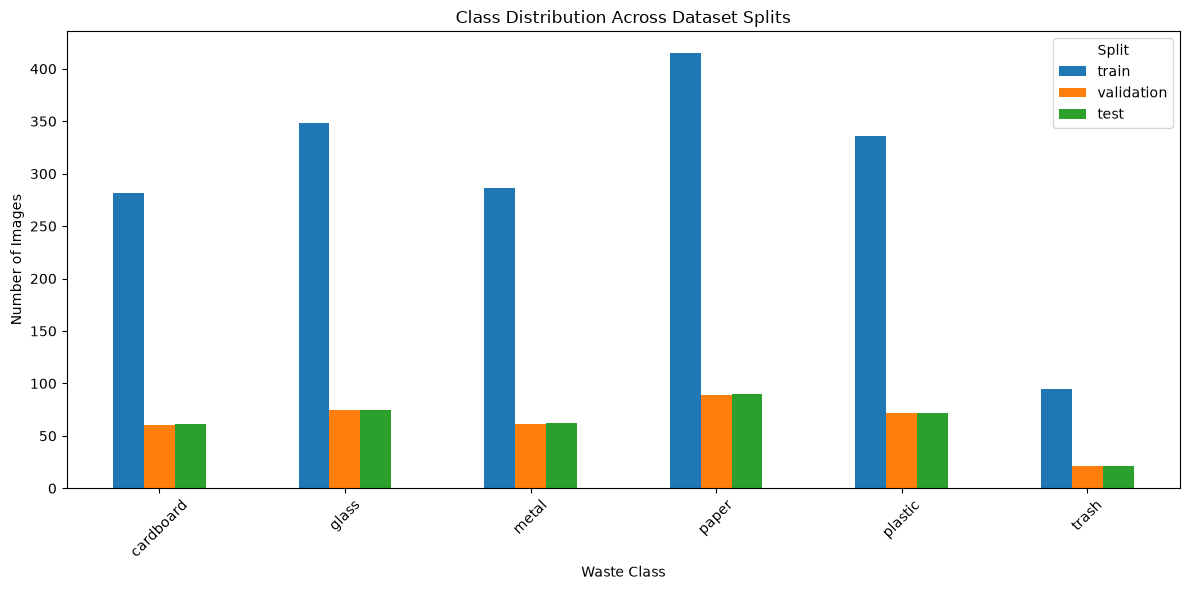

In [20]:
split_plot_data = (
    split_df
    .groupby(["class_name", "split"])
    .size()
    .unstack(fill_value=0)
)

split_plot_data = split_plot_data[
    [
        "train",
        "validation",
        "test",
    ]
]

split_plot_data.plot(
    kind="bar",
    figsize=(12, 6),
)

plt.title("Class Distribution Across Dataset Splits")
plt.xlabel("Waste Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.legend(title="Split")
plt.tight_layout()
plt.show()

### Split-Balance Observation

The training set contains the largest portion of each class, while the
validation and test sets contain smaller but similar proportions.

Because splitting was performed independently within each class, the class
distribution remains approximately consistent across all three splits.

Small percentage differences are expected because image counts must be whole
numbers.

##  Data-Leakage Verification

Data leakage occurs when information from the validation or test set becomes
available during model training.

In image classification, one form of leakage occurs when identical image
content appears in more than one dataset split.

SHA-256 hashes will be used to verify that no identical file appears across
training, validation, and test sets.

In [21]:
hash_split_counts = (
    split_df
    .groupby("sha256")["split"]
    .nunique()
)

leaking_hashes = hash_split_counts[
    hash_split_counts > 1
]

print(
    "Hashes appearing in multiple splits:",
    len(leaking_hashes),
)

Hashes appearing in multiple splits: 0


In [22]:
assert len(leaking_hashes) == 0, (
    "Data leakage detected: identical file content "
    "appears in multiple splits."
)

print("Hash-based leakage check passed.")

Hash-based leakage check passed.


## Checking for repeated source assignments

In [23]:
repeated_source_files = split_df[
    split_df.duplicated(
        subset=["source_path"],
        keep=False,
    )
]

print(
    "Repeated source assignments:",
    len(repeated_source_files),
)

Repeated source assignments: 0


In [24]:
assert len(repeated_source_files) == 0, (
    "One or more source files were assigned multiple times."
)

print("Source-assignment check passed.")

Source-assignment check passed.


## Checking for repeated destination paths

In [25]:
repeated_destination_files = split_df[
    split_df.duplicated(
        subset=["destination_path"],
        keep=False,
    )
]

print(
    "Repeated destination paths:",
    len(repeated_destination_files),
)

Repeated destination paths: 0


In [26]:
assert len(repeated_destination_files) == 0, (
    "One or more destination paths were used multiple times."
)

print("Destination-path check passed.")

Destination-path check passed.


## Verifying all copied files exist

In [27]:
missing_destination_files = []

for destination_path in split_df["destination_path"]:
    full_path = project_root / destination_path

    if not full_path.exists():
        missing_destination_files.append(
            destination_path
        )

print(
    "Missing processed files:",
    len(missing_destination_files),
)

Missing processed files: 0


In [28]:
assert len(missing_destination_files) == 0, (
    "One or more processed image files are missing."
)

print("Processed-file existence check passed.")

Processed-file existence check passed.


## Confirming excluded files are absent

In [29]:
excluded_paths = set(
    exclusion_df["source_path"]
)

included_source_paths = set(
    split_df["source_path"]
)

excluded_files_in_splits = (
    excluded_paths
    .intersection(included_source_paths)
)

print(
    "Excluded files found in processed splits:",
    len(excluded_files_in_splits),
)

Excluded files found in processed splits: 0


In [30]:
assert len(excluded_files_in_splits) == 0, (
    "A conflicting duplicate was included in a split."
)

print("Duplicate-exclusion check passed.")

Duplicate-exclusion check passed.


## Adding one combined integrity check

In [31]:
assert not split_df.empty, (
    "The split manifest is empty."
)

assert set(split_df["split"].unique()) == {
    "train",
    "validation",
    "test",
}, "Unexpected or missing split names."

assert set(split_df["class_name"].unique()) == set(
    classes
), "Unexpected or missing class names."

assert split_df["sha256"].notna().all(), (
    "Missing SHA-256 values found."
)

print("All dataset integrity checks passed successfully.")

All dataset integrity checks passed successfully.


## 1 Deterministic Image Preprocessing

Neural networks require images to have a consistent size and numeric format.

The evaluation preprocessing pipeline performs:

1. resizing to 224 × 224 pixels
2. conversion from a PIL image to a PyTorch tensor
3. normalization using ImageNet mean and standard deviation values

This pipeline is deterministic. The same image always produces the same
processed tensor.

It will be used for:

- validation
- testing
- production inference

Random training augmentation will be implemented separately.

In [32]:
IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225,
]

evaluation_transform = transforms.Compose(
    [
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)

print(evaluation_transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## Testing the preprocessing pipeline

In [33]:
sample_processed_path = (
    project_root
    / split_df.iloc[0]["destination_path"]
)

with Image.open(sample_processed_path) as image:
    sample_image = image.convert("RGB")
    transformed_tensor = evaluation_transform(
        sample_image
    )

print("Original image size:", sample_image.size)
print(
    "Transformed tensor shape:",
    transformed_tensor.shape,
)
print(
    "Tensor data type:",
    transformed_tensor.dtype,
)
print(
    "Tensor minimum:",
    transformed_tensor.min().item(),
)
print(
    "Tensor maximum:",
    transformed_tensor.max().item(),
)

Original image size: (512, 384)
Transformed tensor shape: torch.Size([3, 224, 224])
Tensor data type: torch.float32
Tensor minimum: -1.5430065393447876
Tensor maximum: 2.1804091930389404


## Visualizing before and after preprocessing

In [34]:
def denormalize_tensor(
    image_tensor,
    mean,
    std,
):
    """Reverse normalization for visualization."""

    image_tensor = image_tensor.clone()

    for channel, channel_mean, channel_std in zip(
        image_tensor,
        mean,
        std,
    ):
        channel.mul_(channel_std)
        channel.add_(channel_mean)

    return image_tensor

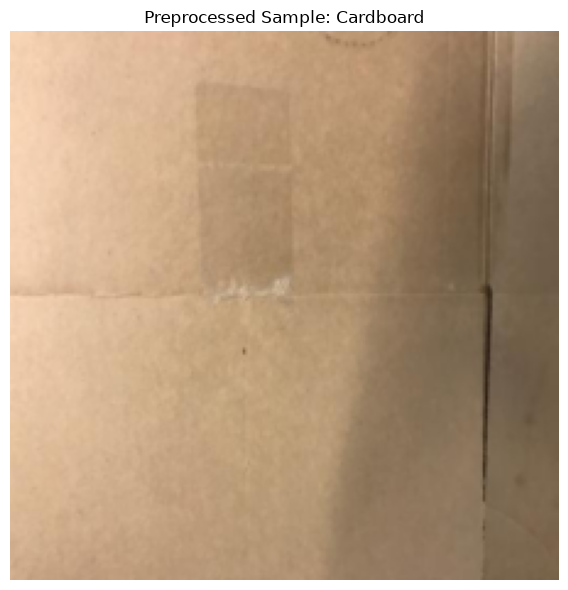

In [35]:
display_tensor = denormalize_tensor(
    transformed_tensor,
    IMAGENET_MEAN,
    IMAGENET_STD,
)

display_image = (
    display_tensor
    .permute(1, 2, 0)
    .clamp(0, 1)
    .numpy()
)

plt.figure(figsize=(6, 6))
plt.imshow(display_image)
plt.title(
    f"Preprocessed Sample: "
    f"{split_df.iloc[0]['class_name'].title()}"
)
plt.axis("off")
plt.tight_layout()
plt.show()


##  Preprocessing Observation

The preprocessing pipeline successfully converts each RGB image into a
PyTorch tensor with shape:

```text
[3, 224, 224]

##  Conclusion

The TrashNet dataset was prepared successfully for model development.

This notebook:

- preserved the original raw dataset
- discovered exact duplicate image content
- excluded cross-class conflicting duplicate groups
- generated an auditable exclusion report
- created reproducible per-class training, validation, and test splits
- saved all split assignments in a manifest
- analyzed class and split balance
- verified that no identical content leaked across splits
- confirmed that every processed file exists
- defined deterministic resizing and ImageNet normalization
- verified the final tensor shape of `[3, 224, 224]`

The processed dataset is now ready for the next stage: reusable preprocessing
modules and training-only data augmentation.